In [1]:
import os, sys, importlib, re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception as e:
    print(f"Could not change directory: {e}")

print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
cdt = importlib.import_module("04_cross_dataset_training")
from model_utils import AUG_SHIFT_MAX_FRAMES, AUG_STRETCH_RANGE

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.3, 'font.size': 9})
print(f"augmentation in force: shift +/-{AUG_SHIFT_MAX_FRAMES:g} frames, "
      f"stretch {AUG_STRETCH_RANGE}")

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



augmentation in force: shift +/-50 frames, stretch (0.85, 1.15)


In [2]:
GROUP_NAME = "final_6_new"
CURVE_TYPE = "ori_curve_sg_p4_norm"
EXP_FOLDER = config.FINAL_EXP_FOLDER
EXCLUDE = ("NC-ALL",)          # PC deliberately kept

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder

def chip_sort_key(s):
    m = re.search(r'DDM_0(\d)', s)
    return int(m.group(1)) if m else s

CHIPS = sorted(config.CROSS_DATASET_GROUPS[GROUP_NAME], key=chip_sort_key)
print(f"{len(CHIPS)} chips")

6 chips


## 1. TTP per (chip, well)

Read each chip's `curve_for_training.joblib` directly rather than going through
`load_curve_data`, because that applies `config.apply_well_exclusion`, which drops
PC and NC. Target wells come from the main `dataset` arrays; PC comes from the
`pc_wells` snapshot that `--drop_pc` wrote alongside them.

In [3]:
rows = []
for chip in CHIPS:
    p = Path(EXP_FOLDER, chip, config.TRAINING_DATA_PATH)
    if not p.exists():
        print(f"  [!] {short_name(chip)}: no training data"); continue
    d = joblib.load(p)
    ts = np.asarray(d["timestamps"], dtype=float)
    try:
        idx, resolved = config.resolve_curve_dataset_idx(CURVE_TYPE, list(d["dataset_name"]))
    except ValueError:
        print(f"  [!] {short_name(chip)}: curve_type {CURVE_TYPE} unavailable"); continue

    curves = np.asarray(d["dataset"][idx])
    Y_well = np.asarray(d["Y_well"])
    lab = config.LABEL_MAPPINGS.get(chip, {})
    conc = config.CONC_MAPPINGS.get(chip, {})

    # target wells (PC/NC already removed from `dataset` by --drop_pc / exclusion)
    for w in np.unique(Y_well):
        target = lab.get(int(w))
        if target is None or target in EXCLUDE:
            continue
        sel = Y_well == w
        ct = cdt.compute_ct_for_curves(curves[sel], ts)
        rows.append({"chip": short_name(chip), "well": int(w), "target": target,
                     "conc": conc.get(int(w)), "n_px": int(sel.sum()), "ttp_s": ct})

    # PC well, from the snapshot
    pc = d.get("pc_wells")
    if pc and resolved in pc.get("curves", {}):
        pc_curves = np.asarray(pc["curves"][resolved])
        pc_well = next((k for k, v in lab.items() if v == "PC"), None)
        ct = cdt.compute_ct_for_curves(pc_curves, ts)
        rows.append({"chip": short_name(chip), "well": pc_well, "target": "PC",
                     "conc": conc.get(pc_well, 0), "n_px": len(pc_curves), "ttp_s": ct})
    else:
        print(f"  [!] {short_name(chip)}: no pc_wells snapshot for {resolved}")
    print(f"  {short_name(chip)} done")

ttp = pd.DataFrame(rows)
ttp["ttp_s"] = pd.to_numeric(ttp["ttp_s"], errors="coerce")
n_bad = ttp["ttp_s"].isna().sum()
if n_bad:
    print(f"\n[!] {n_bad} wells had no fittable Ct -- dropped")
ttp = ttp.dropna(subset=["ttp_s"]).reset_index(drop=True)
print(f"\n{len(ttp)} (chip, well) TTPs")
print(ttp.sort_values(["chip", "well"]).to_string(index=False))

  Chip 01 done


  Chip 02 done


  Chip 03 done


  Chip 04 done


  Chip 05 done


  Chip 06 done

54 (chip, well) TTPs
   chip  well target    conc  n_px      ttp_s
Chip 01     0    IAV 1000000  1942 168.369682
Chip 01     1    IAV  100000  1871 216.902252
Chip 01     2    IAV   10000  1914 244.029134
Chip 01     3    IBV   10000  1807 371.517569
Chip 01     4     Kp  100000  1713 324.137041
Chip 01     5    Cov 1000000  1894 305.366919
Chip 01     6   Hadv 1000000  1874 389.462371
Chip 01     7   Hadv  100000  1680 459.605219
Chip 01     8     PC       0  1828 321.257406
Chip 02     0    IBV 1000000  1924 197.926902
Chip 02     1    IBV  100000  1881 224.623705
Chip 02     2    IBV   10000  1918 327.759131
Chip 02     3    IAV 1000000  1949 175.702822
Chip 02     4    IAV  100000  1930 217.744749
Chip 02     5     Kp   10000  1756 369.944869
Chip 02     6    Cov  100000  1732 389.386763
Chip 02     7   Hadv   10000  1720 472.401601
Chip 02     8     PC       0  1865 323.913685
Chip 03     0     Kp 1000000  1904 264.692355
Chip 03     1     Kp  100000  1668 446.9448

## 2. Aggregate by target x concentration

Mean +/- std across chips for each (target, concentration) cell. `n` is the number
of contributing (chip, well) units — note it varies, because chip layouts are
bespoke and some targets have replicate wells on a chip.

In [4]:
def _conc_label(c):
    if c is None or (isinstance(c, float) and np.isnan(c)):
        return "n/a"
    try:
        v = float(c)
    except (TypeError, ValueError):
        return str(c)
    return "0" if v == 0 else f"1e{int(round(np.log10(v)))}"

ttp["conc_label"] = ttp["conc"].map(_conc_label)

agg = (ttp.groupby(["target", "conc_label"])["ttp_s"]
          .agg(n="size", mean="mean", std="std", min="min", max="max")
          .reset_index())
agg["range_s"] = agg["max"] - agg["min"]
agg["cv_pct"] = 100 * agg["std"] / agg["mean"]
print("TTP (s) by target x concentration, across chips:\n")
print(agg.round(2).to_string(index=False))

print("\n\nPivot -- mean +/- std (s):\n")
piv = ttp.pivot_table(index="target", columns="conc_label", values="ttp_s",
                      aggfunc=["mean", "std"])
print(piv.round(1).to_string())

TTP (s) by target x concentration, across chips:

target conc_label  n   mean    std    min    max  range_s  cv_pct
   Cov        1e4  3 531.39 129.18 432.67 677.58   244.92   24.31
   Cov        1e5  4 456.15  51.16 389.39 512.74   123.35   11.22
   Cov        1e6  3 382.42  72.56 305.37 449.44   144.07   18.97
  Hadv        1e4  4 628.35 105.81 472.40 695.39   222.99   16.84
  Hadv        1e5  3 490.90  29.94 459.61 519.26    59.66    6.10
  Hadv        1e6  3 454.00  88.60 389.46 555.01   165.55   19.52
   IAV        1e4  3 324.46 136.12 244.03 481.62   237.59   41.95
   IAV        1e5  3 264.22  81.24 216.90 358.03   141.12   30.75
   IAV        1e6  3 203.62  54.83 168.37 266.80    98.43   26.93
   IBV        1e4  4 272.08 183.21   0.00 389.04   389.04   67.34
   IBV        1e5  3 339.94 127.90 224.62 477.51   252.89   37.62
   IBV        1e6  3 281.47  96.00 197.93 386.33   188.41   34.11
    Kp        1e4  3 467.57 119.40 369.94 600.70   230.75   25.54
    Kp        1e5  3 396.7

## 3. Compare against the augmentation range

The augmentation operates on the **resampled** grid, so the spread has to be
converted from seconds to resampled frames before it can be compared to
`AUG_SHIFT_MAX_FRAMES`. The grid spacing comes from the actual pooled resampler.

In [5]:
exp_paths = [Path(EXP_FOLDER, c) for c in CHIPS]
combined = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE)
t_grid = combined["resampler"].t_grid
DT = float(np.median(np.diff(t_grid)))
T = len(t_grid)
print(f"resampled grid: {T} points, dt = {DT:.3f} s, duration = {t_grid[-1]:.0f} s")

# Within-cell spread = what augmentation must cover, per target x concentration.
agg["std_frames"] = agg["std"] / DT
agg["range_frames"] = agg["range_s"] / DT
print(f"\nCross-chip spread per (target, conc), in resampled frames "
      f"(augmentation shift is +/-{AUG_SHIFT_MAX_FRAMES:g}):\n")
print(agg[["target", "conc_label", "n", "mean", "std", "std_frames", "range_frames"]]
      .round(2).to_string(index=False))

multi = agg[agg["n"] >= 3]
print(f"\nAcross cells with n>=3 chips ({len(multi)} cells):")
print(f"  median cross-chip std : {multi['std_frames'].median():.1f} frames "
      f"({multi['std'].median():.0f} s)")
print(f"  max    cross-chip std : {multi['std_frames'].max():.1f} frames")
print(f"  median cross-chip range: {multi['range_frames'].median():.1f} frames")
print(f"  max    cross-chip range: {multi['range_frames'].max():.1f} frames")
print(f"\n  AUG_SHIFT_MAX_FRAMES = {AUG_SHIFT_MAX_FRAMES:g}")
print(f"  -> shift covers {AUG_SHIFT_MAX_FRAMES / multi['std_frames'].median():.1f}x "
      f"the median cross-chip std")

# Dilation: TTP ratio spread relative to the grand mean, per target.
gm = ttp.groupby("target")["ttp_s"].transform("mean")
ttp["ttp_ratio"] = ttp["ttp_s"] / gm
lo, hi = ttp["ttp_ratio"].min(), ttp["ttp_ratio"].max()
print(f"\nTTP as a ratio to each target's own cross-chip mean: "
      f"{lo:.3f} to {hi:.3f}  ({100*(lo-1):+.1f}% to {100*(hi-1):+.1f}%)")
print(f"  AUG_STRETCH_RANGE = {AUG_STRETCH_RANGE}  "
      f"({100*(AUG_STRETCH_RANGE[0]-1):+.0f}% to {100*(AUG_STRETCH_RANGE[1]-1):+.0f}%)")

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_05_01


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 3637 samples from wells [6, 8, 9] (y_label={6: 'IBV', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_06_02


  [*] Resampling curves onto common grid: 903 points, duration=2310


resampled grid: 903 points, dt = 2.561 s, duration = 2310 s

Cross-chip spread per (target, conc), in resampled frames (augmentation shift is +/-50):

target conc_label  n   mean    std  std_frames  range_frames
   Cov        1e4  3 531.39 129.18       50.44         95.63
   Cov        1e5  4 456.15  51.16       19.98         48.17
   Cov        1e6  3 382.42  72.56       28.33         56.26
  Hadv        1e4  4 628.35 105.81       41.32         87.07
  Hadv        1e5  3 490.90  29.94       11.69         23.29
  Hadv        1e6  3 454.00  88.60       34.60         64.64
   IAV        1e4  3 324.46 136.12       53.15         92.77
   IAV        1e5  3 264.22  81.24       31.72         55.11
   IAV        1e6  3 203.62  54.83       21.41         38.43
   IBV        1e4  4 272.08 183.21       71.54        151.91
   IBV        1e5  3 339.94 127.90       49.94         98.75
   IBV        1e6  3 281.47  96.00       37.48         73.57
    Kp        1e4  3 467.57 119.40       46.62         9

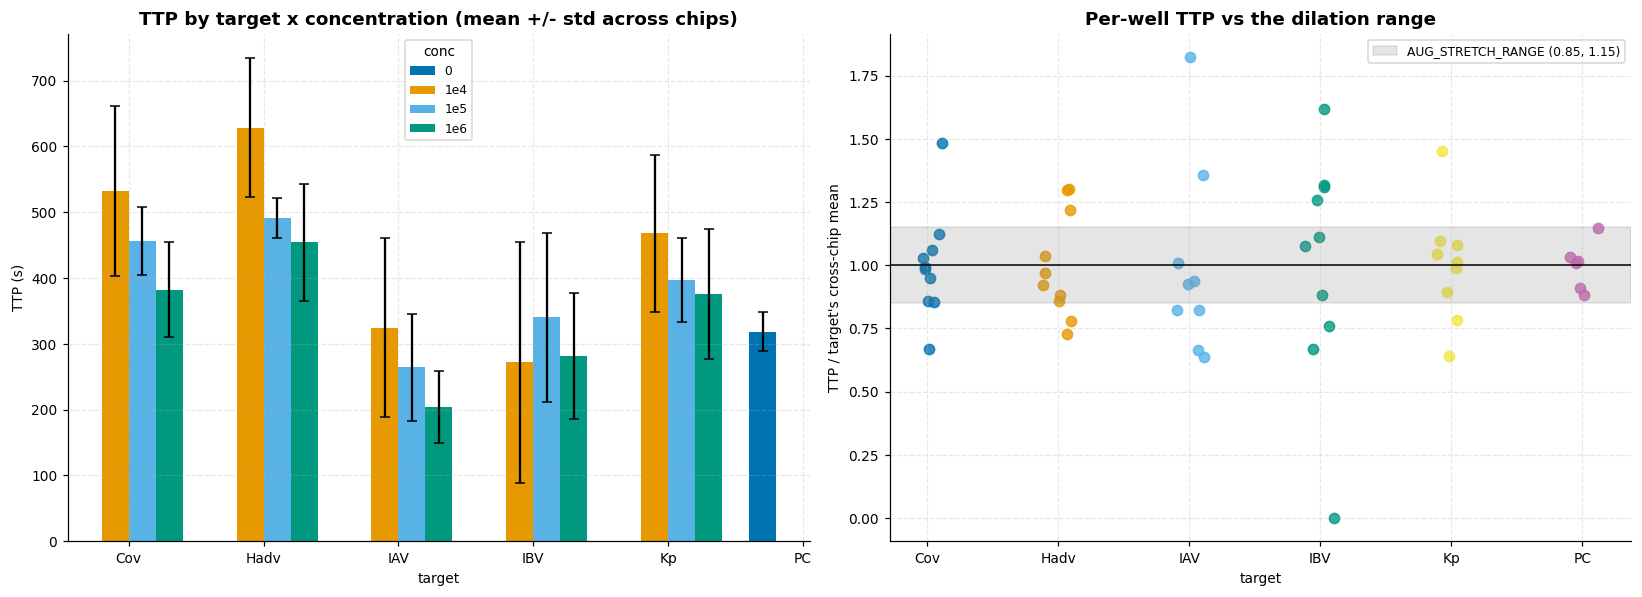

In [6]:
order = sorted(ttp["target"].unique())
concs = sorted(ttp["conc_label"].unique(), key=lambda s: (s == "n/a", s))
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
x = np.arange(len(order)); w = 0.8 / max(len(concs), 1)
for i, c in enumerate(concs):
    sub = ttp[ttp["conc_label"] == c]
    m = [sub[sub.target == t]["ttp_s"].mean() for t in order]
    s = [sub[sub.target == t]["ttp_s"].std() for t in order]
    ax.bar(x + (i - (len(concs)-1)/2)*w, m, width=w, yerr=s, capsize=3, label=c)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("TTP (s)"); ax.set_xlabel("target")
ax.set_title("TTP by target x concentration (mean +/- std across chips)",
             fontsize=12, fontweight="bold")
ax.legend(title="conc", fontsize=8)

# Per-well TTP relative to its target's mean, with the augmentation band overlaid.
ax = axes[1]
for i, t in enumerate(order):
    sub = ttp[ttp.target == t]
    ax.scatter(np.full(len(sub), i) + np.random.uniform(-0.12, 0.12, len(sub)),
               sub["ttp_ratio"], s=45, alpha=0.8)
ax.axhspan(AUG_STRETCH_RANGE[0], AUG_STRETCH_RANGE[1], color="grey", alpha=0.2,
           label=f"AUG_STRETCH_RANGE {AUG_STRETCH_RANGE}")
ax.axhline(1.0, color="black", lw=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
ax.set_ylabel("TTP / target's cross-chip mean"); ax.set_xlabel("target")
ax.set_title("Per-well TTP vs the dilation range", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()